In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
df = pd.read_csv("../data/processed/acn_sessions_clean.csv",  parse_dates=[
        "connectionTime",
        "disconnectTime",
        "doneChargingTime"
    ])
df.head()

,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,stationID,kWhRequested,minutesAvailable,sessionDurationHours,chargingDurationHours,idleDurationHours
0,2018-04-25 04:08:04,2018-04-25 06:20:10,2018-04-25 06:21:10,7.932,2-39-78-362,NaN,NaN,2.201667,2.218333,0.000000
1,2018-04-25 06:45:10,2018-04-25 17:56:16,2018-04-25 09:44:15,10.013,2-39-95-27,NaN,NaN,11.185000,2.984722,8.200278
2,2018-04-25 06:45:50,2018-04-25 16:04:45,2018-04-25 07:51:44,5.257,2-39-79-380,NaN,NaN,9.315278,1.098333,8.216944
3,2018-04-25 07:37:06,2018-04-25 16:55:34,2018-04-25 09:05:22,5.177,2-39-79-379,NaN,NaN,9.307778,1.471111,7.836667
4,2018-04-25 07:40:34,2018-04-25 16:03:12,2018-04-25 10:40:30,10.119,2-39-79-381,NaN,NaN,8.377222,2.998889,5.378333


## DataSet Overview

In [6]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14973 entries, 0 to 14972
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   connectionTime         14973 non-null  datetime64[ns]
 1   disconnectTime         14973 non-null  datetime64[ns]
 2   doneChargingTime       14973 non-null  datetime64[ns]
 3   kWhDelivered           14973 non-null  float64       
 4   stationID              14973 non-null  object        
 5   kWhRequested           2230 non-null   float64       
 6   minutesAvailable       2230 non-null   float64       
 7   sessionDurationHours   14973 non-null  float64       
 8   chargingDurationHours  14973 non-null  float64       
 9   idleDurationHours      14973 non-null  float64       
dtypes: datetime64[ns](3), float64(6), object(1)
memory usage: 1.1+ MB


In [7]:
df.isnull().sum()

connectionTime               0
disconnectTime               0
doneChargingTime             0
kWhDelivered                 0
stationID                    0
kWhRequested             12743
minutesAvailable         12743
sessionDurationHours         0
chargingDurationHours        0
idleDurationHours            0
dtype: int64

In [8]:
df

,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,stationID,kWhRequested,minutesAvailable,sessionDurationHours,chargingDurationHours,idleDurationHours
0,2018-04-25 04:08:04,2018-04-25 06:20:10,2018-04-25 06:21:10,7.932,2-39-78-362,NaN,NaN,2.201667,2.218333,0.000000
1,2018-04-25 06:45:10,2018-04-25 17:56:16,2018-04-25 09:44:15,10.013,2-39-95-27,NaN,NaN,11.185000,2.984722,8.200278
2,2018-04-25 06:45:50,2018-04-25 16:04:45,2018-04-25 07:51:44,5.257,2-39-79-380,NaN,NaN,9.315278,1.098333,8.216944
3,2018-04-25 07:37:06,2018-04-25 16:55:34,2018-04-25 09:05:22,5.177,2-39-79-379,NaN,NaN,9.307778,1.471111,7.836667
4,2018-04-25 07:40:34,2018-04-25 16:03:12,2018-04-25 10:40:30,10.119,2-39-79-381,NaN,NaN,8.377222,2.998889,5.378333
...,...,...,...,...,...,...,...,...,...,...
14968,2018-12-15 14:22:57,2018-12-15 15:36:35,2018-12-15 15:23:26,6.554,2-39-138-29,21.42,137.0,1.227222,1.008056,0.219167
14969,2018-12-15 15:02:07,2018-12-16 05:22:44,2018-12-16 00:29:42,58.873,2-39-79-380,94.68,529.0,14.343611,9.459722,4.883889
14970,2018-12-15 15:06:40,2018-12-15 15:49:53,2018-12-15 15:49:44,4.356,2-39-92-436,8.64,109.0,0.720278,0.717778,0.002500
14971,2018-12-15 15:34:41,2018-12-15 22:27:36,2018-12-15 17:22:27,5.212,2-39-126-20,9.99,320.0,6.881944,1.796111,5.085833


In [9]:
print(df[[ "sessionDurationHours", "chargingDurationHours", "idleDurationHours", "kWhDelivered"]].describe())

       sessionDurationHours  chargingDurationHours  idleDurationHours  \
count          14973.000000           14973.000000       14973.000000   
mean               5.921653               3.240374           2.682058   
std                6.439383               3.184923           5.365291   
min                0.087500               0.000000           0.000000   
25%                2.027222               1.275000           0.001389   
50%                4.766667               2.245556           0.736944   
75%                8.730556               4.245833           4.179444   
max              245.269167             104.428333         156.121389   

       kWhDelivered  
count  14973.000000  
mean       9.012230  
std        7.056089  
min        0.501000  
25%        4.018000  
50%        7.450000  
75%       13.205000  
max       69.373000  


In [10]:
df.nlargest(500,"idleDurationHours")[[ "connectionTime", "disconnectTime", "kWhDelivered", "stationID", "sessionDurationHours", "idleDurationHours"]]
# We notice that many people just leave their vehicle there for a very long duration of time. 

,connectionTime,disconnectTime,kWhDelivered,stationID,sessionDurationHours,idleDurationHours
13320,2018-11-05 19:49:25,2018-11-12 09:54:23,6.276,2-39-79-378,158.082778,156.121389
13489,2018-11-09 02:33:02,2018-11-19 07:49:11,1.479,2-39-127-19,245.269167,140.840833
5541,2018-07-26 08:58:18,2018-07-31 14:46:57,4.346,2-39-124-22,125.810833,123.988333
3711,2018-06-27 19:21:46,2018-07-02 09:17:31,6.711,2-39-79-379,109.929167,107.633889
11053,2018-10-04 20:16:12,2018-10-09 07:43:00,11.257,2-39-126-20,107.446667,104.089722
...,...,...,...,...,...,...
1583,2018-05-23 18:25:20,2018-05-24 06:51:03,13.564,2-39-125-21,12.428611,10.282222
14763,2018-12-11 08:02:46,2018-12-11 20:28:12,4.837,2-39-79-379,12.423889,10.268889
9648,2018-09-18 08:42:46,2018-09-18 20:20:48,4.336,2-39-131-30,11.633889,10.261389
9092,2018-09-11 09:22:11,2018-09-11 20:34:52,1.824,2-39-123-557,11.211389,10.260278


In [11]:
(df["idleDurationHours"] > 16).sum()
df[df["idleDurationHours"] > 16].sort_values(by='idleDurationHours').tail()
# df["idleDurationHours"].quantile(
#     [0.90,0.95,0.99,0.995,0.999]
# )
threshold = df["idleDurationHours"].quantile(0.99)

top_1pct = df[df["idleDurationHours"] >= threshold]

len(top_1pct)
top_1pct["weekday"].value_counts()

# df.columns

KeyError: 'weekday'

In [ ]:
mask = (
    ((df["weekday"] == "Friday") & (df["idleDurationHours"] >= 72)) |
    ((df["weekday"] == "Saturday") & (df["idleDurationHours"] >= 48)) |
    ((~df["weekday"].isin(["Friday", "Saturday"])) & (df["idleDurationHours"] >= 20))
)

filtered_df = df[mask]
filtered_df["weekday"].value_counts()

weekday
Monday       13
Wednesday    12
Tuesday      11
Thursday     10
Sunday        9
Friday        3
Saturday      1
Name: count, dtype: int64

In [ ]:
for col in df.columns:
    print(col, ":", df[col].nunique())

connectionTime : 14938
disconnectTime : 14944
doneChargingTime : 14912
kWhDelivered : 9674
stationID : 54
kWhRequested : 269
minutesAvailable : 581
sessionDurationHours : 11538
chargingDurationHours : 9878
idleDurationHours : 7561


## Temporal Demand Analysis

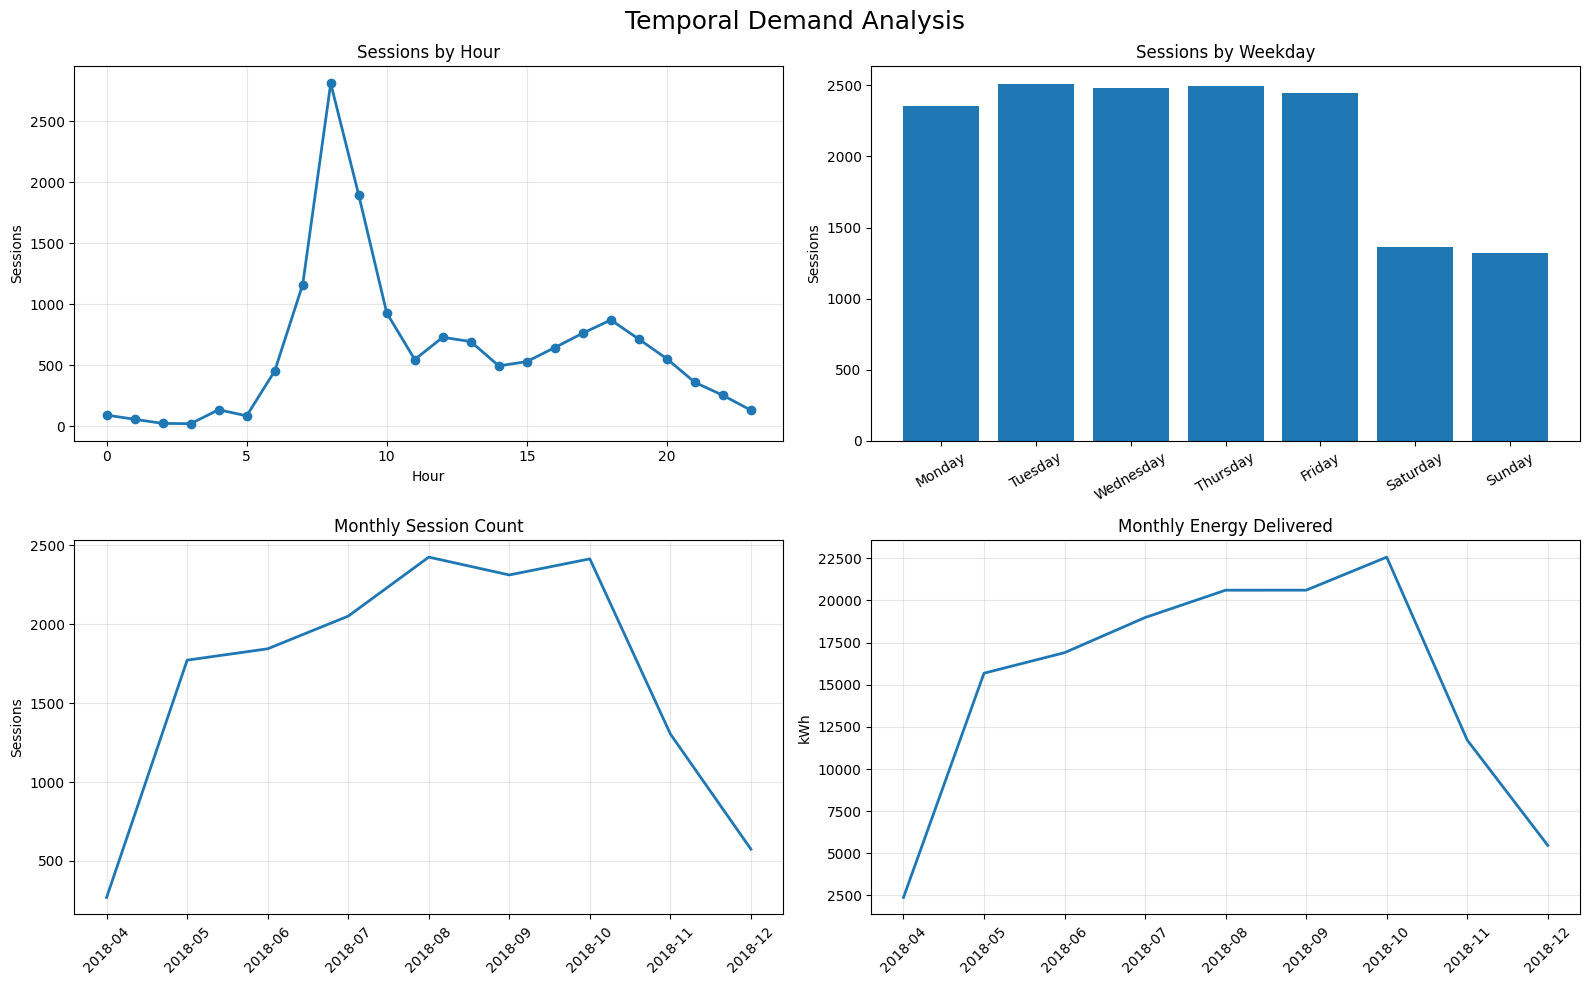

In [ ]:
df["hour"] = df["connectionTime"].dt.hour
df["weekday"] = df["connectionTime"].dt.day_name()
df["year_month"] = df["connectionTime"].dt.to_period("M")

weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

hourly_sessions = df.groupby("hour").size()
weekday_sessions = df["weekday"].value_counts().reindex(weekday_order)
monthly_sessions = df.groupby("year_month").size()
monthly_energy = df.groupby("year_month")["kWhDelivered"].sum()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(hourly_sessions.index, hourly_sessions.values, marker="o", linewidth=2)
axes[0,0].set_title("Sessions by Hour")
axes[0,0].set_xlabel("Hour")
axes[0,0].set_ylabel("Sessions")
axes[0,0].grid(alpha=0.3)

axes[0,1].bar(weekday_sessions.index, weekday_sessions.values)
axes[0,1].set_title("Sessions by Weekday")
axes[0,1].set_ylabel("Sessions")
axes[0,1].tick_params(axis="x", rotation=30)

axes[1,0].plot(monthly_sessions.index.astype(str), monthly_sessions.values, linewidth=2)
axes[1,0].set_title("Monthly Session Count")
axes[1,0].set_ylabel("Sessions")
axes[1,0].tick_params(axis="x", rotation=45)
axes[1,0].grid(alpha=0.3)

axes[1,1].plot(monthly_energy.index.astype(str), monthly_energy.values, linewidth=2)
axes[1,1].set_title("Monthly Energy Delivered")
axes[1,1].set_ylabel("kWh")
axes[1,1].tick_params(axis="x", rotation=45)
axes[1,1].grid(alpha=0.3)

fig.suptitle("Temporal Demand Analysis", fontsize=18)
plt.tight_layout()
plt.show()

## Charging Behaviour

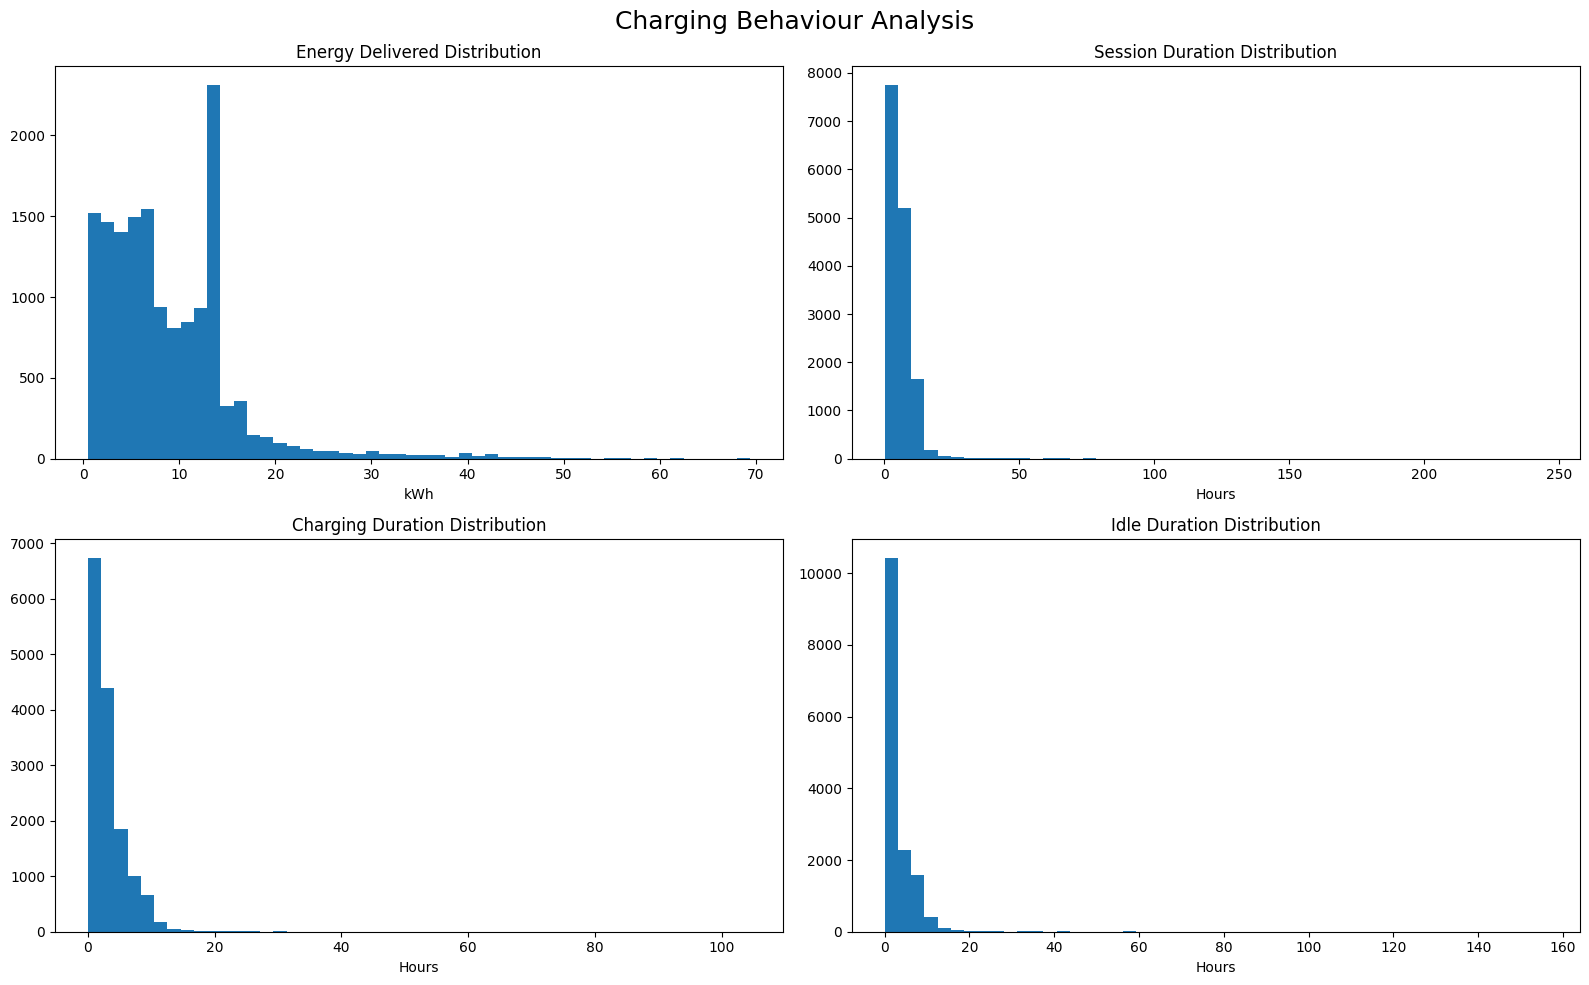

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].hist(df["kWhDelivered"], bins=50)
axes[0,0].set_title("Energy Delivered Distribution")
axes[0,0].set_xlabel("kWh")

axes[0,1].hist(df["sessionDurationHours"], bins=50)
axes[0,1].set_title("Session Duration Distribution")
axes[0,1].set_xlabel("Hours")

axes[1,0].hist(df["chargingDurationHours"], bins=50)
axes[1,0].set_title("Charging Duration Distribution")
axes[1,0].set_xlabel("Hours")

axes[1,1].hist(df["idleDurationHours"], bins=50)
axes[1,1].set_title("Idle Duration Distribution")
axes[1,1].set_xlabel("Hours")

fig.suptitle("Charging Behaviour Analysis", fontsize=18)
plt.tight_layout()
plt.show()

## Station Analysis And Relationships

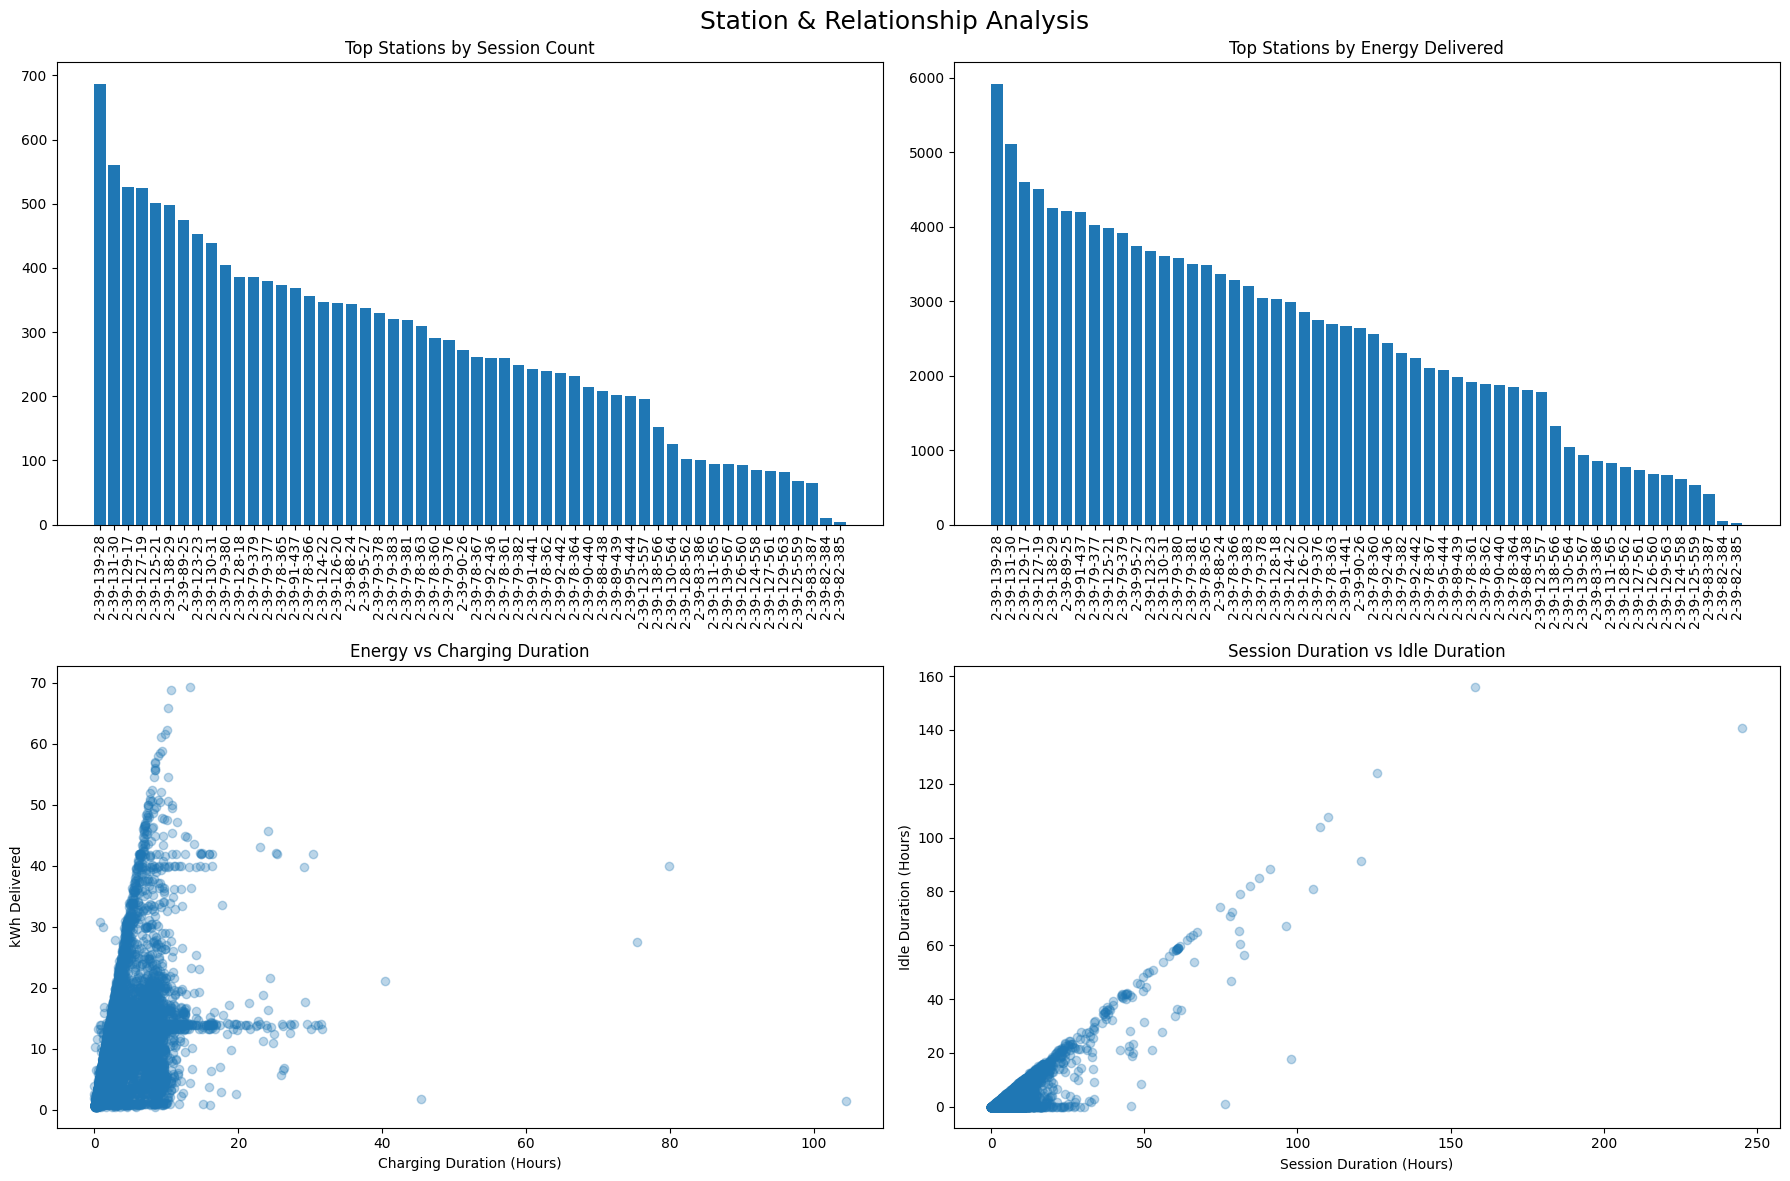

In [ ]:
station_sessions = df["stationID"].value_counts()

station_energy = df.groupby("stationID")["kWhDelivered"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0,0].bar(station_sessions.index, station_sessions.values)
axes[0,0].set_title("Top Stations by Session Count")
axes[0,0].tick_params(axis="x", rotation=90)

axes[0,1].bar(station_energy.index, station_energy.values)
axes[0,1].set_title("Top Stations by Energy Delivered")
axes[0,1].tick_params(axis="x", rotation=90)

axes[1,0].scatter(df["chargingDurationHours"], df["kWhDelivered"], alpha=0.3)
axes[1,0].set_title("Energy vs Charging Duration")
axes[1,0].set_xlabel("Charging Duration (Hours)")
axes[1,0].set_ylabel("kWh Delivered")

axes[1,1].scatter(df["sessionDurationHours"], df["idleDurationHours"], alpha=0.3)
axes[1,1].set_title("Session Duration vs Idle Duration")
axes[1,1].set_xlabel("Session Duration (Hours)")
axes[1,1].set_ylabel("Idle Duration (Hours)")

fig.suptitle("Station & Relationship Analysis", fontsize=18)
plt.tight_layout()
plt.show()

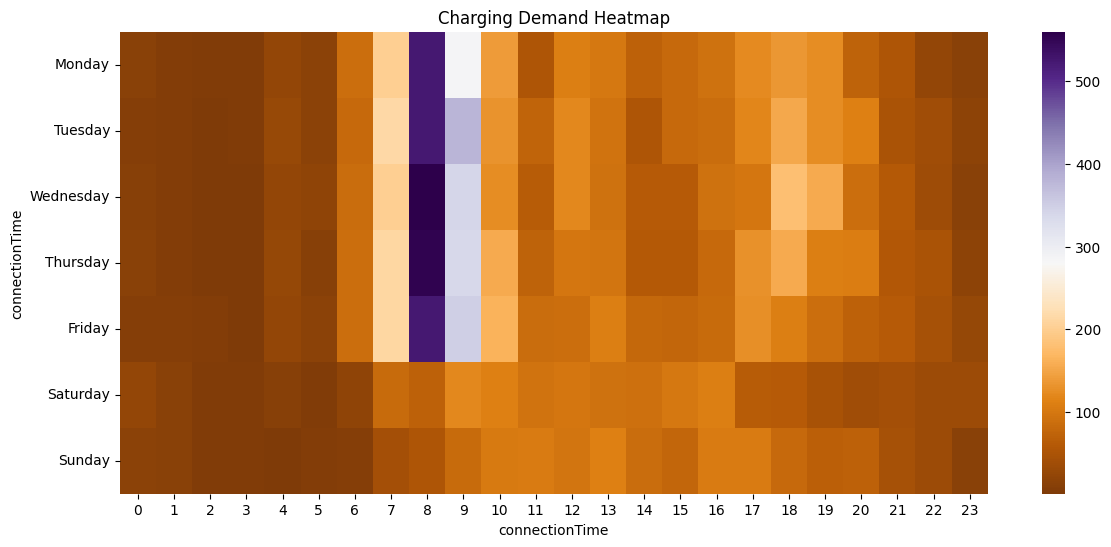

In [ ]:
pivot = pd.pivot_table(
    df,
    index=df["connectionTime"].dt.day_name(),
    columns=df["connectionTime"].dt.hour,
    values="kWhDelivered",
    aggfunc="count"
)

pivot = pivot.reindex(weekday_order)
plt.figure(figsize=(14,6))
sns.heatmap(pivot,cmap="PuOr")
plt.title("Charging Demand Heatmap")
plt.show()

### User Input Analysis

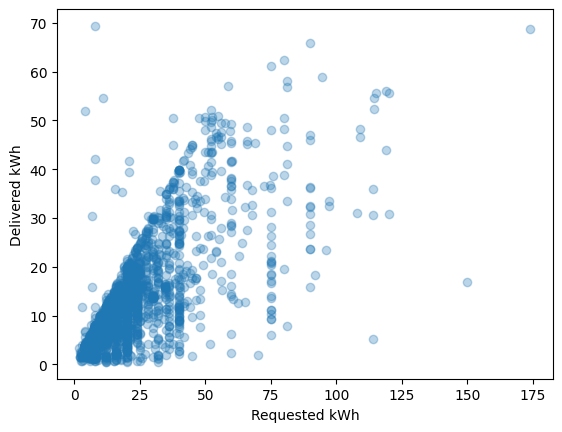

In [ ]:
subset = df.dropna(subset=["kWhRequested"])

plt.scatter( subset["kWhRequested"], subset["kWhDelivered"], alpha=0.3)

plt.xlabel("Requested kWh")
plt.ylabel("Delivered kWh")
plt.show()

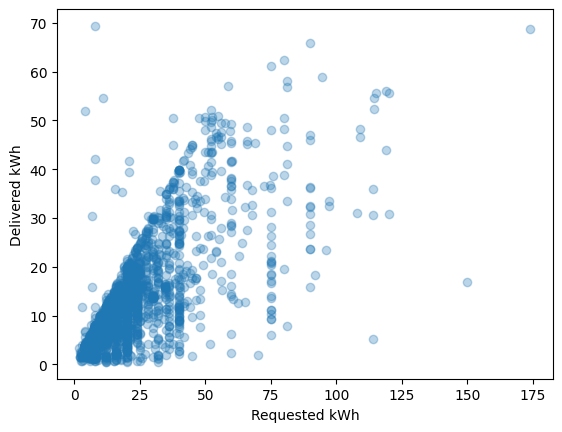

In [ ]:
subset = df.dropna(subset=["kWhRequested"])

plt.scatter( subset["kWhRequested"], subset["kWhDelivered"], alpha=0.3)

plt.xlabel("Requested kWh")
plt.ylabel("Delivered kWh")
plt.show()

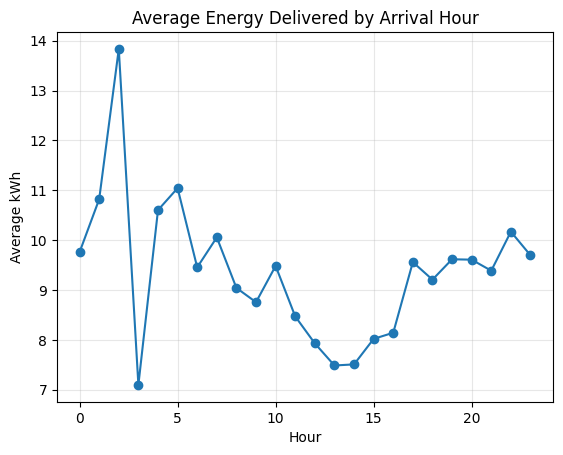

In [ ]:
avg_kwh_hour = df.groupby(df["connectionTime"].dt.hour)["kWhDelivered"].mean()

avg_kwh_hour.plot(marker="o")

plt.title("Average Energy Delivered by Arrival Hour")
plt.xlabel("Hour")
plt.ylabel("Average kWh")
plt.grid(alpha=0.3)
plt.show()

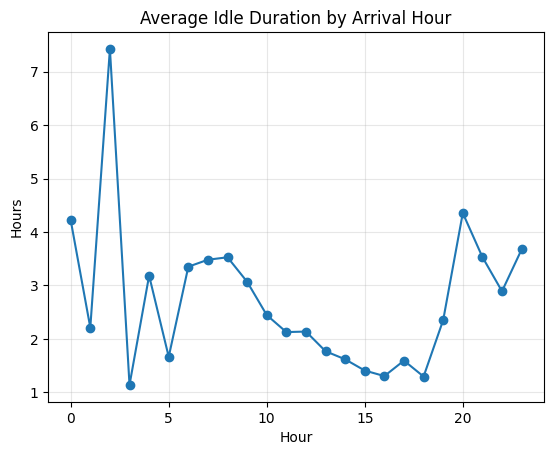

In [ ]:
avg_idle = df.groupby(df["connectionTime"].dt.hour)["idleDurationHours"].mean()

avg_idle.plot(marker="o")
plt.title("Average Idle Duration by Arrival Hour")
plt.xlabel("Hour")
plt.ylabel("Hours")
plt.grid(alpha=0.3)
plt.show()